In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent.notebook_imports import *

In [35]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from waymo_agent.action_heuristic.heuristic_simple import PricingAgent, DispatchAgent, RepositionAgent
from waymo_agent.models.ppo_model import RideShareActorCritic
from waymo_agent.graph_env.ENV import RideShareEnv
from waymo_agent.models.ppo_model import *
from waymo_agent.data_classes.config import ENV_CFG_240step_V08_L01_MR_100_MRNew_20
from waymo_agent.models.torch_np_utils import load_weights

In [5]:
from waymo_agent.models.ppo_model import *
from waymo_agent.models.evaluate import *
from waymo_agent.models.train_utils import *
from waymo_agent.models.train_ppo import train_ppo

In [6]:
from kret_sandbox.VIS import dtt
from kret_sandbox.exp_decay import exp_decay_half_life, get_gamma_from_half_life

# ENV Setup

In [7]:
def get_obs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides


def get_obs_tuple_from_obs(obs: ObservationDict):
    veh = obs["vehicles"]
    req = obs["pending_requests"]
    rides = obs["active_rides"]
    return veh, req, rides

In [36]:
env_cfg = ENV_CFG_240step_V08_L01_MR_100_MRNew_20
waymo_env = RideShareEnv(env_cfg)

Assigned lambda values to nodes. Total lambda: 7.8200 (target: 7.8200)


In [37]:
GAMMA = get_gamma_from_half_life(env_cfg.max_episode_steps // 2)
round(GAMMA, 5)

0.99424

In [38]:
model_cfg = ActorCriticConfig(hidden_size=256)

# Train PPO

In [39]:
actor_critic_model = RideShareActorCritic(waymo_env, model_cfg)

In [40]:
from waymo_agent.models.train_utils import PPO_TRN_CFG_TS5k_Debug_EvalEp2

cfg_ppo_train = PPO_TRN_CFG_TS5k_Debug_EvalEp2

In [41]:
pprint(cfg_ppo_train)

PPOTrainConfig(total_steps=5000,
               debug=True,
               gamma=0.997,
               gae_lambda=0.95,
               lr=0.0003,
               clip_eps=0.2,
               vf_coef=0.5,
               ent_coef=0.01,
               max_grad_norm=0.5,
               update_epochs=5,
               minibatch_size=256,
               deterministic_eval=True,
               log_every_updates=5,
               eval_episodes=2,
               eval_every_updates=1,
               patience=20,
               min_delta=0.001,
               save_best=True)


In [42]:
print(env_cfg)

EnvConfig(map_name='manhattan-sparse-782-nodes-enriched.graphml', map_dir=PosixPath('/Users/Akseldkw/coding/Columbia/RL-Project/maps'), vehicle_per_node=0.08, max_vehicles=50, time_step_delta=datetime.timedelta(seconds=60), max_episode_steps=240, day_per_week=7, hours_per_day=24, lambda_per_node=0.01, lambda_variation_coef=2.0, max_new_requests_per_step=20, max_pending_requests=100, max_wait_time_minutes=15, max_price=inf, invalid_id=-1, acceptance_margin_weight=-2.0, acceptance_supply_demand_weight=3.0, battery_consumption_per_km=0.01, charge_rate_per_minute=0.12, min_battery_for_assignment=0.2, chargable_node_ratio=0.01, max_chargers_per_node=1, penalty_rejected=-0.01, penalty_expire=-0.5, penalty_overflow=0, reward_frac_ride_completion=15.0, operating_cost_per_km=1.0, verbose_rewards=True, shaped_reward_config=RewardShapingConfig(penalty_multiple_dispatch_assignment=-0.1, penalty_assign_to_unavailable_vehicle=-0.2, distance_penalty_xy_normed=-0.05))


In [43]:
model_name = f"ppo_model_V-{waymo_env.config.vehicle_per_node:.2f}_L-{waymo_env.config.lambda_per_node:.2f}_H-{actor_critic_model.model_cfg.hidden_size}_NV-{waymo_env.num_vehicles}_MR-{waymo_env.config.max_pending_requests}"
model_name

'ppo_model_V-0.08_L-0.01_H-256_NV-50_MR-100'

In [44]:
save_path = MODEL_WEIGHT_DIR / f"{model_name}.pt"

In [45]:
load_weights(actor_critic_model, MODEL_WEIGHT_DIR / save_path, DEVICE_TORCH_STR)

RideShareActorCritic(
  (encoder): SharedEncoder(
    (net): Sequential(
      (0): Linear(in_features=1908, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
    )
  )
  (pricing): PricingHead(
    (mu): Linear(in_features=256, out_features=100, bias=True)
  )
  (reposition): RepositionHead(
    (mu): Linear(in_features=256, out_features=100, bias=True)
  )
  (dispatch): DispatchHead(
    (logits_layer): Linear(in_features=256, out_features=5100, bias=True)
  )
  (value): Linear(in_features=256, out_features=1, bias=True)
)

In [46]:
# raise ValueError("Stop here")


actor_critic_model, logs = train_ppo(waymo_env, actor_critic_model, train_cfg=cfg_ppo_train, save_path=save_path)

PPO steps:   0%|          | 0/5000 [00:00<?, ?step/s]

PPO update epochs:   0%|          | 0/5 [00:00<?, ?epoch/s]

PPO evaluation episodes:   0%|          | 0/2 [00:00<?, ?episodes/s]

[eval] update=0  eval_return=-1986.401


PPO update epochs:   0%|          | 0/5 [00:00<?, ?epoch/s]

...

PPO update epochs:   0%|          | 0/5 [00:00<?, ?epoch/s]

PPO update epochs:   0%|          | 0/5 [00:00<?, ?epoch/s]

PPO update epochs:   0%|          | 0/5 [00:00<?, ?epoch/s]

PPO evaluation episodes:   0%|          | 0/2 [00:00<?, ?episodes/s]

[eval] update=20  eval_return=-2081.592


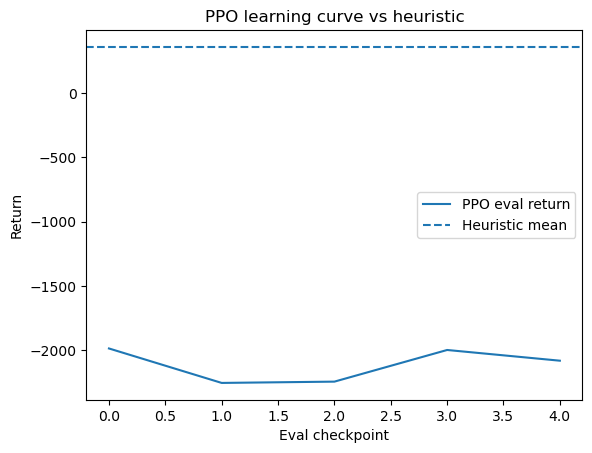

In [47]:
plot_learning_curve_vs_baseline(logs, heur_mean=env_cfg.max_episode_steps * 1.5)